In [19]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set()
import warnings
warnings.filterwarnings('ignore')

In [20]:
e = df = pd.read_csv('E-com_Data.csv')
df.head()

,CustomerID,Item Code,InvoieNo,Date of purchase,Quantity,Time,price per Unit,Price,Shipping Location,Cancelled_status,Reason of return,Sold as set
0,4355.0,15734,398177.0,29-10-2017,6.0,3:36:00 PM,321.0,1926.0,Location 1,NaN,NaN,NaN
1,4352.0,14616,394422.0,05-10-2017,2.0,2:53:00 PM,870.0,1740.0,Location 1,NaN,NaN,NaN
2,4352.0,14614,394422.0,12-10-2017,2.0,2:53:00 PM,933.0,1866.0,Location 1,NaN,NaN,NaN
3,4352.0,85014B,388633.0,22-08-2017,3.0,2:47:00 PM,623.0,1869.0,Location 1,NaN,NaN,NaN
4,4352.0,15364,394422.0,10-10-2017,2.0,2:53:00 PM,944.0,1888.0,Location 1,NaN,NaN,NaN


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 405270 entries, 0 to 405269
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         397228 non-null  float64
 1   Item Code          405270 non-null  object 
 2   InvoieNo           405269 non-null  float64
 3   Date of purchase   405269 non-null  object 
 4   Quantity           405269 non-null  float64
 5   Time               405269 non-null  object 
 6   price per Unit     405269 non-null  float64
 7   Price              405269 non-null  float64
 8   Shipping Location  405269 non-null  object 
 9   Cancelled_status   8065 non-null    object 
 10  Reason of return   0 non-null       float64
 11  Sold as set        0 non-null       float64
dtypes: float64(7), object(5)
memory usage: 37.1+ MB


In [22]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
CustomerID,397228.0,2213.395783,1234.407616,2.0,1260.0,2121.0,3306.0,4372.0
InvoieNo,405269.0,385592.420086,13142.273535,361429.0,374076.0,386774.0,397129.0,406651.0
Quantity,405269.0,11.144326,28.962709,-310.0,2.0,5.0,12.0,3186.0
price per Unit,405269.0,342.795751,425.038228,1.0,159.0,239.0,410.0,64973.0
Price,405269.0,2412.991275,4806.771469,-10152.0,532.0,1530.0,2448.0,90400.0
Reason of return,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sold as set,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [23]:
df.columns

Index(['CustomerID', 'Item Code', 'InvoieNo', 'Date of purchase', 'Quantity',
       'Time', 'price per Unit', 'Price', 'Shipping Location',
       'Cancelled_status', 'Reason of return', 'Sold as set'],
      dtype='object')

In [24]:
drop_columns = ['Item Code','Quantity','price per Unit','Time','Shipping Location','Cancelled_status','Reason of return','Sold as set']
df.drop(columns = drop_columns, inplace = True)

In [25]:
df.head()

,CustomerID,InvoieNo,Date of purchase,Price
0,4355.0,398177.0,29-10-2017,1926.0
1,4352.0,394422.0,05-10-2017,1740.0
2,4352.0,394422.0,12-10-2017,1866.0
3,4352.0,388633.0,22-08-2017,1869.0
4,4352.0,394422.0,10-10-2017,1888.0


In [26]:
df.duplicated().sum()

np.int64(1302)

In [27]:
df.drop_duplicates(inplace = True)

In [28]:
df.duplicated().sum()

np.int64(0)

In [29]:
df.Price.min()

-10152.0

In [30]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
CustomerID,395932.0,2213.633028,1234.387590,2.0,1260.0,2123.0,3306.0,4372.0
InvoieNo,403967.0,385586.387801,13141.611949,361429.0,374059.0,386766.0,397126.0,406651.0
Price,403967.0,2416.258294,4811.608775,-10152.0,534.0,1532.0,2450.0,90400.0


In [31]:
def missing_values(df):
  missing_number = df.isnull().sum().sort_values(ascending = False)
  missing_percent = (df.isnull().sum()/df.isnull().count()*100).sort_values(ascending = False)
  missing_values = pd.concat([missing_number,missing_percent],keys  = ['missing_number','missing_percent'], axis = 1)
  return missing_values[missing_values['missing_number']>0]
missing_values(df)

,missing_number,missing_percent
CustomerID,8036,1.989266
InvoieNo,1,0.000248
Date of purchase,1,0.000248
Price,1,0.000248


In [32]:
df = df.dropna(subset = ['CustomerID'])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 395932 entries, 0 to 405269
Data columns (total 4 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   CustomerID        395932 non-null  float64
 1   InvoieNo          395931 non-null  float64
 2   Date of purchase  395931 non-null  object 
 3   Price             395931 non-null  float64
dtypes: float64(3), object(1)
memory usage: 15.1+ MB


In [33]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
CustomerID,395932.0,2213.633028,1234.387590,2.0,1260.0,2123.0,3306.0,4372.0
InvoieNo,395931.0,385631.242345,13113.065959,361429.0,374189.0,386923.0,397129.0,406651.0
Price,395931.0,2436.717067,4821.409829,-10152.0,547.0,1554.0,2472.0,90400.0


In [34]:
df['Date of purchase'] = pd.to_datetime(df['Date of purchase'])

In [35]:
df['Date of purchase'].describe().T

,Date of purchase
count,395931
mean,2017-07-15 11:45:55.380103936
min,2016-12-02 00:00:00
25%,2017-04-12 00:00:00
50%,2017-08-04 00:00:00
75%,2017-10-26 00:00:00
max,2017-12-19 00:00:00


In [36]:
df = df.rename(columns = {'InvoieNo':'InvoiceNo','Date of purchase':'Date'})

In [37]:
df.head()

,CustomerID,InvoiceNo,Date,Price
0,4355.0,398177.0,2017-10-29,1926.0
1,4352.0,394422.0,2017-10-05,1740.0
2,4352.0,394422.0,2017-10-12,1866.0
3,4352.0,388633.0,2017-08-22,1869.0
4,4352.0,394422.0,2017-10-10,1888.0


In [38]:
df['CustomerID'].nunique()

4337

In [39]:
import datetime
new_date = datetime.datetime(2017,12,20)
new_date

datetime.datetime(2017, 12, 20, 0, 0)

In [40]:
df['CustomerID'] ==4352

,CustomerID
0,False
1,True
2,True
3,True
4,True
...,...
405265,False
405266,False
405267,False
405268,False


In [41]:
RFM = df.groupby('CustomerID').agg({'Date':lambda x:(new_date-x.max()).days,
                                    'InvoiceNo':lambda x:x.count(),
                                    'Price':lambda x:x.sum()})
RFM.rename(columns = {'Date':'Recency','InvoiceNo':'Frequency','Price':'Monetary'}, inplace = True)
RFM.reset_index()

,CustomerID,Recency,Frequency,Monetary
0,2.0,9,33,93730.0
1,3.0,328,3,38448.0
2,4.0,19,8,18051.0
3,6.0,73,5,7596.0
4,8.0,233,6,13980.0
...,...,...,...,...
4332,4368.0,278,10,20480.0
4333,4369.0,181,7,10774.0
4334,4370.0,9,13,24962.0
4335,4371.0,4,751,279720.0


In [42]:
RFM.describe().T

,count,mean,std,min,25%,50%,75%,max
Recency,4337.0,93.428176,100.696488,1.0,18.0,52.0,144.0,381.0
Frequency,4337.0,91.291446,230.192197,1.0,16.0,40.0,99.0,7881.0
Monetary,4337.0,222451.423818,828201.945456,-50372.0,36648.0,80616.0,200035.0,35461289.0


In [43]:
quantiles = RFM.quantile(q = [0.25,0.5,0.75])
quantiles = quantiles.to_dict()
quantiles

{'Recency': {0.25: 18.0, 0.5: 52.0, 0.75: 144.0},
 'Frequency': {0.25: 16.0, 0.5: 40.0, 0.75: 99.0},
 'Monetary': {0.25: 36648.0, 0.5: 80616.0, 0.75: 200035.0}}

In [44]:
def Recency_value(x,p,d):
  if x<=d[p][0.25]:
    return 1
  elif x<=d[p][0.5]:
    return 2
  elif x<=d[p][0.75]:
    return 3
  else:
    return 4


In [45]:
def Freq_mont_value(x,p,d):
  if x<=d[p][0.25]:
    return 4
  elif x<=d[p][0.5]:
    return 3
  elif x<=d[p][0.75]:
    return 2
  else:
    return 1


In [46]:
RFM['R'] = RFM['Recency'].apply(Recency_value, args = ('Recency',quantiles))
RFM['F'] = RFM['Frequency'].apply(Freq_mont_value, args = ('Frequency',quantiles))
RFM['M'] = RFM['Monetary'].apply(Freq_mont_value, args = ('Monetary',quantiles))

In [47]:
RFM.reset_index()

,CustomerID,Recency,Frequency,Monetary,R,F,M
0,2.0,9,33,93730.0,1,3,2
1,3.0,328,3,38448.0,4,4,3
2,4.0,19,8,18051.0,2,4,4
3,6.0,73,5,7596.0,3,4,4
4,8.0,233,6,13980.0,4,4,4
...,...,...,...,...,...,...,...
4332,4368.0,278,10,20480.0,4,4,4
4333,4369.0,181,7,10774.0,4,4,4
4334,4370.0,9,13,24962.0,1,4,4
4335,4371.0,4,751,279720.0,1,1,1


In [48]:
RFM['RFM'] = RFM[['R','F','M']].sum(axis = 1)
RFM.reset_index()

,CustomerID,Recency,Frequency,Monetary,R,F,M,RFM
0,2.0,9,33,93730.0,1,3,2,6
1,3.0,328,3,38448.0,4,4,3,11
2,4.0,19,8,18051.0,2,4,4,10
3,6.0,73,5,7596.0,3,4,4,11
4,8.0,233,6,13980.0,4,4,4,12
...,...,...,...,...,...,...,...,...
4332,4368.0,278,10,20480.0,4,4,4,12
4333,4369.0,181,7,10774.0,4,4,4,12
4334,4370.0,9,13,24962.0,1,4,4,9
4335,4371.0,4,751,279720.0,1,1,1,3


In [49]:
RFM.to_csv('RFMapproach.csv')

In [50]:
RFM['RFM'].value_counts()

,count
RFM,
10,518
3,468
7,462
9,461
5,436
8,430
6,415
12,395
11,379


In [51]:
Loyalty_level = ['platinum','gold','silver','bronze']
score_cuts = pd.qcut(RFM.RFM,q = 4,labels = Loyalty_level)
RFM['Loyalty_level'] = score_cuts.values
RFM

,Recency,Frequency,Monetary,R,F,M,RFM,Loyalty_level
CustomerID,,,,,,,,
2.0,9,33,93730.0,1,3,2,6,gold
3.0,328,3,38448.0,4,4,3,11,bronze
4.0,19,8,18051.0,2,4,4,10,silver
6.0,73,5,7596.0,3,4,4,11,bronze
8.0,233,6,13980.0,4,4,4,12,bronze
...,...,...,...,...,...,...,...,...
4368.0,278,10,20480.0,4,4,4,12,bronze
4369.0,181,7,10774.0,4,4,4,12,bronze
4370.0,9,13,24962.0,1,4,4,9,silver


In [52]:
RFM = RFM.reset_index()
RFM

,CustomerID,Recency,Frequency,Monetary,R,F,M,RFM,Loyalty_level
0,2.0,9,33,93730.0,1,3,2,6,gold
1,3.0,328,3,38448.0,4,4,3,11,bronze
2,4.0,19,8,18051.0,2,4,4,10,silver
3,6.0,73,5,7596.0,3,4,4,11,bronze
4,8.0,233,6,13980.0,4,4,4,12,bronze
...,...,...,...,...,...,...,...,...,...
4332,4368.0,278,10,20480.0,4,4,4,12,bronze
4333,4369.0,181,7,10774.0,4,4,4,12,bronze
4334,4370.0,9,13,24962.0,1,4,4,9,silver
4335,4371.0,4,751,279720.0,1,1,1,3,platinum


In [53]:
RFM['Loyalty_level'].value_counts()

,count
Loyalty_level,
gold,1307
platinum,1277
silver,979
bronze,774


In [54]:
RFM.to_csv('Loyalty_level.csv')

In [55]:
RFM.columns

Index(['CustomerID', 'Recency', 'Frequency', 'Monetary', 'R', 'F', 'M', 'RFM',
       'Loyalty_level'],
      dtype='object')

In [60]:
Final_report = RFM.groupby('Loyalty_level')[['Recency','Frequency','Monetary','CustomerID']].agg({
    'Recency':'max',
    'Frequency':'sum',
    'Monetary':'sum',
    'CustomerID':'nunique'
}).reset_index()

In [61]:
Final_report

,Loyalty_level,Recency,Frequency,Monetary,CustomerID
0,platinum,144,291265,738317804.0,1277
1,gold,371,73633,160236775.0,1307
2,silver,374,23109,49001851.1,979
3,bronze,381,7924,17215395.0,774


In [65]:
Final_report = Final_report.rename(columns = {'CustomerID':'Buyers'})
Final_report

,Loyalty_level,Recency,Frequency,Monetary,Buyers
0,platinum,144,291265,738317804.0,1277
1,gold,371,73633,160236775.0,1307
2,silver,374,23109,49001851.1,979
3,bronze,381,7924,17215395.0,774


In [66]:
Final_report['Percent'] = round(Final_report['Buyers']/Final_report['Buyers'].sum()*100,2)

In [67]:
Final_report

,Loyalty_level,Recency,Frequency,Monetary,Buyers,Percent
0,platinum,144,291265,738317804.0,1277,29.44
1,gold,371,73633,160236775.0,1307,30.14
2,silver,374,23109,49001851.1,979,22.57
3,bronze,381,7924,17215395.0,774,17.85


In [68]:
final_report_1 = Final_report[['Loyalty_level','Buyers','Percent']]

In [69]:
final_report_1

,Loyalty_level,Buyers,Percent
0,platinum,1277,29.44
1,gold,1307,30.14
2,silver,979,22.57
3,bronze,774,17.85


In [71]:
!pip install squarify

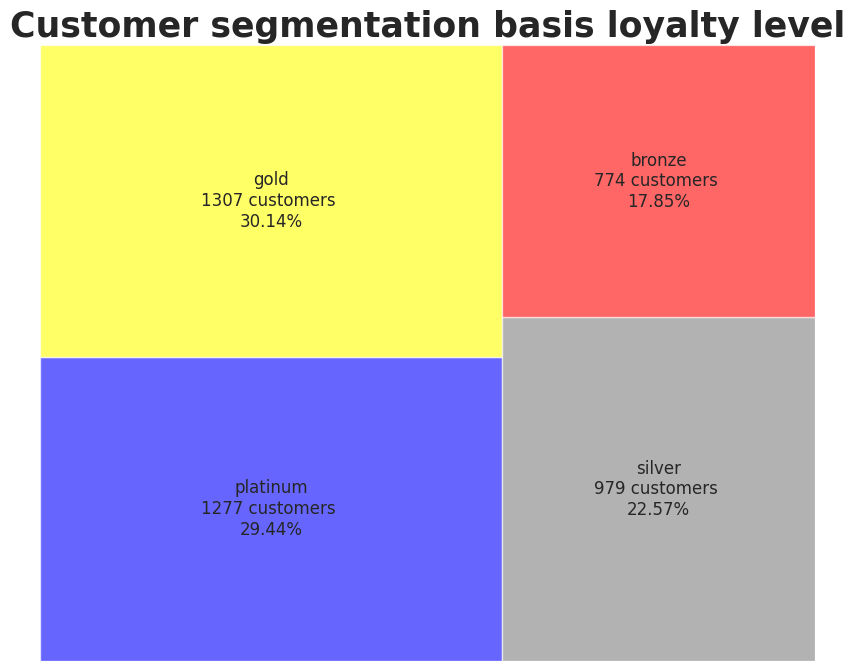

In [73]:
import squarify
fig = plt.gcf()
ax = fig.add_subplot()
fig.set_size_inches(10,8)
color_dics = {'platinum':'blue','gold':'yellow','silver':'gray','bronze':'red'}

squarify.plot(sizes = final_report_1['Buyers'], color = color_dics.values(),
              label = ['{}\n{:0.0f} customers \n{}%'.format(*final_report_1.iloc[i])for i in range(0,len(final_report_1))],alpha = 0.6)
plt.title('Customer segmentation basis loyalty level',fontsize = 25, fontweight = 'bold')
plt.axis('off')
plt.show()